In [2]:
#library(clusterProfiler)
library(tidyverse)
library(dplyr)
library(msigdbr)
#library(enrichplot)
library(DOSE)
library(ggplot2)
library(dplyr)
library(tidyr)



DOSE v3.24.2  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use DOSE in published research, please cite:
Guangchuang Yu, Li-Gen Wang, Guang-Rong Yan, Qing-Yu He. DOSE: an R/Bioconductor package for Disease Ontology Semantic and Enrichment analysis. Bioinformatics 2015, 31(4):608-609




In [4]:
signature_path<-'/mnt/cold2/snaketree/prj/PPH/local/share/data/signature_paperPaneth/'
#BARRIGA Secretory_progenitor ok
#MerlosSuarex LateTA+,Hu-Lgr5-ISC, Proliferation per ora come EMT ok
#HE Goblet 
#REHman Diapause Like

In [130]:
#Barriga:SEC progenitors
barriga_path<-paste0(signature_path,'/gene_sets.gmt')
line <- readLines(barriga_path)
fields <- strsplit(line, "\\s+")[[1]]
col_name <- fields[1]
genes <- fields[-c(1, 2)]
barriga <- data.frame(genes)
colnames(barriga) <-'gene'
barriga$class<-col_name


In [79]:
#Merlos
merlos_path<-paste0(signature_path,'/MerlozSuarez.csv')
merlos<-read.table(merlos_path,sep=',',stringsAsFactors = FALSE)
merlos<-merlos[5:nrow(merlos),]
merlos$V6<-NULL
colnames(merlos)<-merlos[1,]
rownames(merlos) <- NULL
merlos <- merlos[-1, ]

library(stringr)

merlos_clean <- merlos %>%
  select(`Hu-Lgr5-ISC`, `HU-Late TA`, `Hu-Proliferation`) %>%
  pivot_longer(
    cols = everything(),
    names_to = "class",
    values_to = "gene"
  ) %>%
  filter(!is.na(gene), str_trim(gene) != "") %>%
  mutate(
    gene = str_remove(gene, "\\*+$")
  )


#Gli asterischi anche porcodioooooooo
sum(grepl("\\*$", merlos_clean$gene))




[1] 0

In [86]:
#HE Paneth
geni<-c('DEFA5', 'DEFA6', 'PLA2G2A','PRSS2', 'REG3A', 'ITLN2')
He <- data.frame(
  gene = geni,
  class = "Paneth",
  stringsAsFactors = FALSE
)

In [103]:
#rehman
rehman_path<-paste0(signature_path,'/rehman.csv')
rehman<-read.table(rehman_path,stringsAsFactors = FALSE,sep=',')
rehman<-rehman[2:nrow(rehman),]
rehman$V4<-NULL
colnames(rehman)<-rehman[1,]
rehman_pos<-rehman[rehman$Weight=='1',]
rehman_clean<-data.frame(
    gene=rehman_pos$Gene,
    class='Diapause-Like'
)

In [127]:
library(dplyr)

prova <- bind_rows(
  rehman_clean,
  He,
  merlos_clean,
  barriga
)
head(prova)

,gene,class
,<chr>,<chr>
1,PDCD4,Diapause-Like
2,ACSS1,Diapause-Like
3,HEXB,Diapause-Like
4,CTSL,Diapause-Like
5,RENBP,Diapause-Like
6,DPP7,Diapause-Like


In [128]:
prova<-prova[,c('class','gene')]
colnames(prova)<-NULL
write.csv(prova, paste0(signature_path,"/all_signature.csv"), row.names = FALSE,quote = FALSE)

In [3]:
#all gsea res
library(tidyverse)

# directory con i file tsv
dir_path <- "/mnt/cold2/snaketree/prj/PPH/dataset/Kmeans/signature_paperPaneth"

# lista di tutti i file .tsv
files <- list.files(
  path = dir_path,
  pattern = "\\.tsv$",
  full.names = TRUE
)

# funzione per leggere e processare un file
read_gsea_tsv <- function(f) {
  
  samplename <- basename(f) %>%
    sub("^GSEA_intestine\\.", "", .) %>%
    sub("_Paneth\\.tsv$", "", .)
  
  df <- read.table(
    f,
    sep = "\t",
    header = TRUE,
    stringsAsFactors = FALSE
  )
  
  df %>%
    select(ID, NES, pvalue) %>%
    mutate(samplename = samplename)
}


# leggi tutti i file e uniscili
gsea_all <- map_dfr(files, read_gsea_tsv)


In [4]:
rownames(gsea_all)<-NULL

In [5]:
library(dplyr)
library(tidyr)

gsea_wide <- gsea_all %>%
  pivot_wider(
    id_cols = ID,
    names_from = samplename,
    values_from = c(NES, pvalue),
    names_glue = "{.value}_{samplename}"
  )


In [6]:
gsea_wide<-as.data.frame(gsea_wide)

In [7]:
rownames(gsea_wide)<-gsea_wide$ID
gsea_wide$ID<-NULL

In [8]:
nes_cols <- grep("^NES_", colnames(gsea_wide), value = TRUE)
nes_cols
pval_cols <- grep("^pvalue_", colnames(gsea_wide), value = TRUE)
pval_cols

[1] "NES_CRC0069_CTX72h_1"  "NES_CRC0069_NT72h_1"   "NES_CRC0322_cetux_1"  
 [4] "NES_CRC0322_NT_1_3000" "NES_CRC0327_cetux_2"   "NES_CRC0327_NT_2"     
 [7] "NES_CRC0542_CTX72h_1"  "NES_CRC0542_NT72h_1"   "NES_CRC1502_cetux_1"  
[10] "NES_CRC1502_NT_1"      "NES_CRC1620_cetux_1"   "NES_CRC1620_NT_1"

[1] "pvalue_CRC0069_CTX72h_1"  "pvalue_CRC0069_NT72h_1"  
 [3] "pvalue_CRC0322_cetux_1"   "pvalue_CRC0322_NT_1_3000"
 [5] "pvalue_CRC0327_cetux_2"   "pvalue_CRC0327_NT_2"     
 [7] "pvalue_CRC0542_CTX72h_1"  "pvalue_CRC0542_NT72h_1"  
 [9] "pvalue_CRC1502_cetux_1"   "pvalue_CRC1502_NT_1"     
[11] "pvalue_CRC1620_cetux_1"   "pvalue_CRC1620_NT_1"

In [16]:
limite <- max(abs(gsea_wide))
library(circlize)

mat_nes <- gsea_wide[, nes_cols]
mat_pval <- gsea_wide[, pval_cols]
library(ComplexHeatmap)
library(circlize)
mat_nes<-as.matrix(mat_nes)
limite <- max((mat_nes), na.rm = TRUE)
#colorRampPalette(c("blue","white","red"))(100)
#limite<-1
colori<-col_fun <- colorRamp2(
  c(-limite, 0, limite),
  c("#4575b4", "white", "#d73027")  
)

ht_nes <- Heatmap(mat_nes,
                  name = "NES",
                  col = colori,
                  cluster_columns = FALSE,
                  cluster_rows = TRUE,
                  show_row_dend = FALSE ,
                  show_row_names = TRUE,
                  row_names_side = "left",
                  row_names_gp = gpar(fontsize = 8),
                  row_names_max_width = unit(12, "cm"),
                  heatmap_legend_param = list(
                    at = c(-limite, 0, limite),
                    labels = c(paste0("-", round(limite, 2)), "0", paste0("+", round(limite, 2))))
                  )
#print(ht_nes)

mat_pval<-as.matrix(mat_pval)
pval_th<-0.05
mat_pval_cat <- ifelse(mat_pval < pval_th, "significativo", "non significativo")
mat_pval_cat[is.na(mat_pval)] <- "NA" 

mat_pval_cat <- as.matrix(mat_pval_cat)


colori_pval <- c("significativo" = "goldenrod", "non significativo" = "lightgrey", "NA" = "white")


ht_pval <- Heatmap(mat_pval_cat,
                   name = "p-value",
                   cluster_rows = FALSE,
                   cluster_columns = FALSE,
                   show_row_names = FALSE,
                   col = colori_pval,
                   rect_gp = gpar(col = "white", lwd = 1),
                   heatmap_legend_param = list(
                     at = c("significativo", "non significativo", "NA"),
                     labels = c(paste0("<", pval_th), paste0(">", pval_th), "NA")
                  ))
pdf('heatmap_signaturePaperPaneth.pdf')
draw(ht_nes + ht_pval, heatmap_legend_side = "right")
graphics.off()
#ggsave(p,filename = 'heatmap_signaturePaperPaneth.pdf')

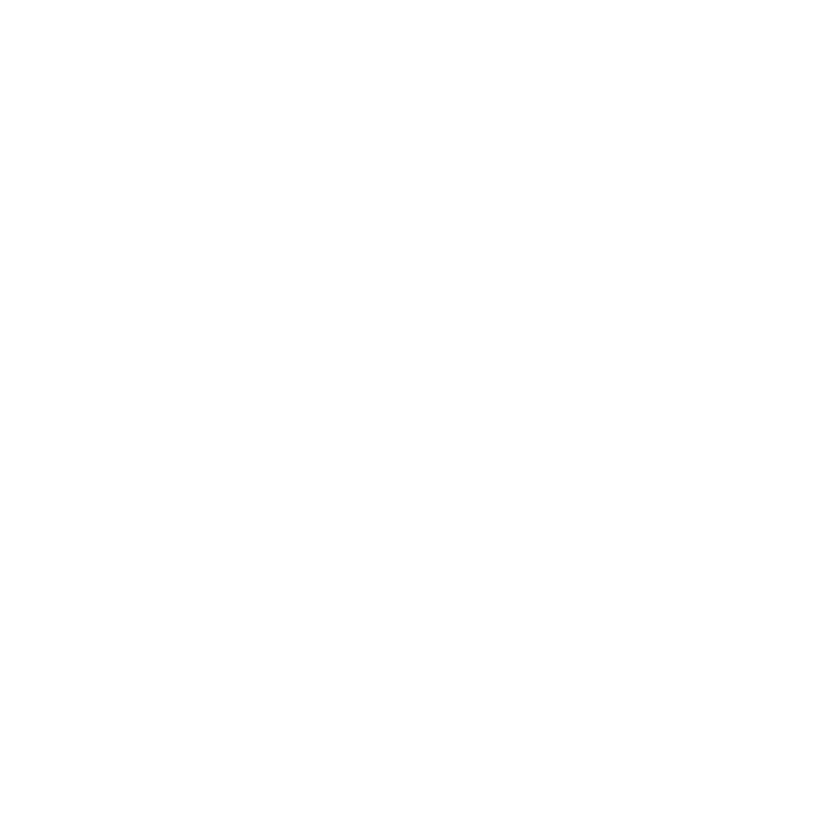

In [10]:
ht_pval